In [289]:
##Case_analysis_

In [246]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [247]:
guild = pd.read_csv("guild_data.csv")
energy = pd.read_csv( "energy.csv")
pd.set_option('display.float_format','{:,.0f}'.format)

In [248]:
print("Размеры датафреймов:")
print("guild_data:", guild.shape)
print("energy:", energy.shape)

Размеры датафреймов:
guild_data: (965, 12)
energy: (971, 3)


In [249]:
guild.describe().T

,count,mean,std,min,25%,50%,75%,max
creator_character_id,965,"23,235,990","3,926,890","10,631,353","21,140,973","23,958,657","26,318,342","29,090,532"
guild_id,965,"72,964","13,100","50,310","61,637","72,964","84,291","95,618"
n_added_characters,965,33,37,1,4,20,49,283
n_removed_characters,866,31,35,1,5,19,47,265
n_talents,672,15,15,1,6,11,20,109
level,572,3,1,2,2,3,4,8
n_missions_completed,895,138,65,1,86,169,171,279
n_times_flag_turned_on,81,2,1,1,1,1,2,8
mean_place,59,15,7,2,10,14,18,35
mean_rating,59,475,53,320,445,477,500,604


In [250]:
energy.describe().T

,count,mean,std,min,25%,50%,75%,max
energy_delta,971,"73,195","142,850",50,"4,200","22,480","71,360","1,148,686"
guild_id,971,"72,661","12,933","50,310","61,614","72,353","84,009","95,618"


In [251]:
energy.head()

,energy_delta,context_type,guild_id
0,1148686,GuildMissionRewardContext,90166
1,1018116,GuildMissionRewardContext,81283
2,907440,GuildMissionRewardContext,79262
3,889109,GuildMissionRewardContext,84667
4,858954,GuildMissionRewardContext,77241


In [252]:
## надо посмотреть на контекст энергии. откуда зарабатывают
energy_context = energy.groupby('context_type').agg(
                 total_energy=('energy_delta', 'sum'),
                 avg_energy=('energy_delta', 'mean'),
                 events=('energy_delta', 'count')).sort_values('total_energy', ascending=False)
energy_context

,total_energy,avg_energy,events
context_type,,,
GuildMissionRewardContext,58473781,"69,529",841
CompleteGuildRaidMatchContext,12116635,"228,616",53
ConvertKnowledgeToGuildEnergyContext,481631,"6,255",77


In [253]:
## обьединяем

In [254]:
guild_features = guild.merge(guild_energy[['guild_id','energy_delta']],on='guild_id',how='left')

guild_features = guild_features.fillna(0)

In [255]:
## проанализируем движение участников
guild_features[['n_added_characters','n_removed_characters']].describe()

,n_added_characters,n_removed_characters
count,965,965
mean,33,28
std,37,34
min,1,0
25%,4,2
50%,20,14
75%,49,44
max,283,265


In [256]:
guild_features['net_members']=(guild_features['n_added_characters'] -guild_features['n_removed_characters'])

In [257]:
guild_features['net_members'].describe()
## слишкомб большая текучка чтобы брать этот признак. Не берем

count   965
mean      5
std       5
min       0
25%       1
50%       4
75%       8
max      23
Name: net_members, dtype: float64

In [258]:
activity_features = [
    'n_missions_completed',
    'energy_delta' 
]
## миссии отражают действия игроков
## энергия отражает результат игровой активности, то есть миссия, рейды,знания
## между ними есть положительная связь (0.45). Частично потому что у нас нет данных о рейдах и знаниях
## участники- >миссии(рейды,знания)-> энергия ->таланты -> уровень ->доступ к магазину, усиление

In [259]:
development_features = [
              'n_talents',
              'level'
]
## энергия тратится на таланты -> таланты повышают уровень гильдии. Поэтому я выбрала за активность только миссии и энергию

In [260]:
guild_features[activity_features].describe()

,n_missions_completed,energy_delta
count,965,965
mean,128,"73,650"
std,72,"198,277"
min,0,0
25%,86,"1,680"
50%,168,"16,580"
75%,171,"61,580"
max,279,"1,847,185"


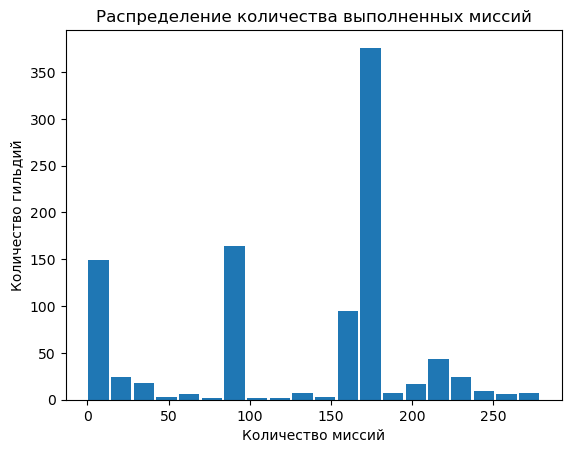

In [261]:
plt.hist(guild_features['n_missions_completed'],bins=20,rwidth=0.9)

plt.title('Распределение количества выполненных миссий')
plt.xlabel('Количество миссий')
plt.ylabel('Количество гильдий')
plt.show()
## видим что миссии распределены пиками.Тоже не получится использовать для деления на классы.

In [262]:
## Проанализировав другие признаки. Решила что признаком для деления на классы активности
## подойдет энергия. Так как энергия зарабатывается с помощью разных активностей(знания,рейд,миссия).
## То есть энергия показательна.
## Участие в войнах, сезонах скорее является следствием после накопления энергии.
## Если энергия низкая, то меньше талантов, меньше уровень и меньше войн.
## Энергия самый показаельный и плавно распределенный признак.

In [263]:
guild_features['activity_class'] = pd.cut(
    guild_features['energy_delta'],
    bins=[-1, 1680, 16580, 61580, float('inf')],
    labels=[
        'Неактивные',
        'Низкая активность',
        'Средняя активность',
        'Высокая активность'
        ])

In [264]:
## cсчитаем гильдии
activity_counts = guild_features['activity_class'].value_counts()
activity_counts

activity_class
Неактивные            250
Средняя активность    241
Высокая активность    241
Низкая активность     233
Name: count, dtype: int64

In [265]:
## считаем доли
activity_share = (guild_features['activity_class'].value_counts(normalize=True)* 100)

activity_share

activity_class
Неактивные           26
Средняя активность   25
Высокая активность   25
Низкая активность    24
Name: proportion, dtype: float64

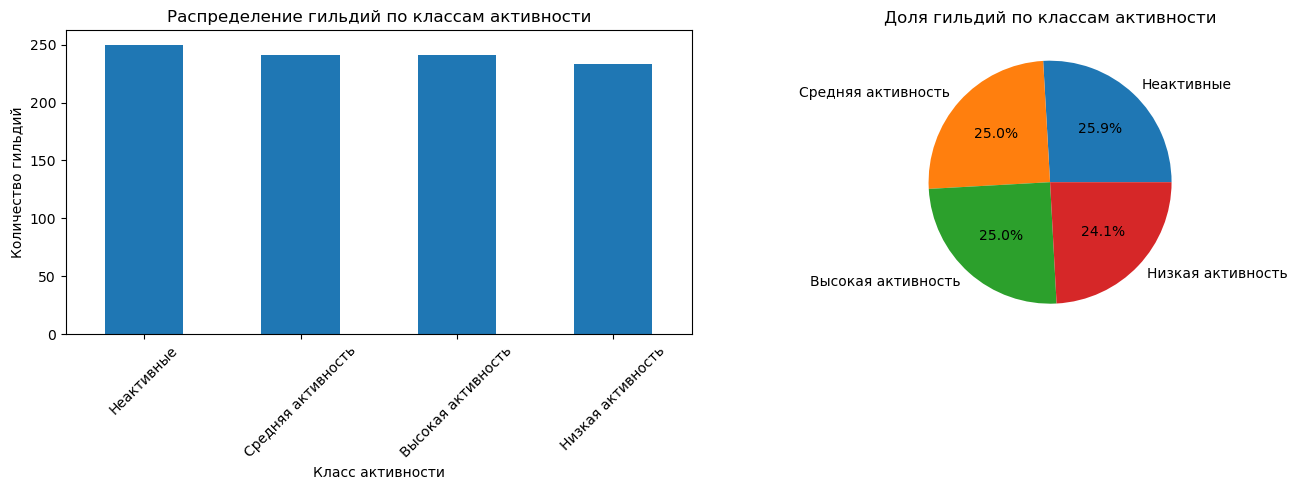

In [266]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
activity_counts.plot(kind='bar',ax=axes[0])
axes[0].set_title('Распределение гильдий по классам активности')
axes[0].set_xlabel('Класс активности')
axes[0].set_ylabel('Количество гильдий')
axes[0].tick_params(axis='x', rotation=45)

activity_share.plot(kind='pie',autopct='%1.1f%%',ax=axes[1])
axes[1].set_title('Доля гильдий по классам активности')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [267]:
guild_features.groupby('activity_class')[['level','n_talents','n_missions_completed']].median()

C:\Users\lidcl\AppData\Local\Temp\ipykernel_12492\103934417.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  guild_features.groupby('activity_class')[['level','n_talents','n_missions_completed']].median()


,level,n_talents,n_missions_completed
activity_class,,,
Неактивные,0,0,10
Низкая активность,0,2,166
Средняя активность,3,11,170
Высокая активность,4,24,174


In [268]:
## видим, по классам активности, два высокие класса имеют уровни и таланты высокие
## два нижних класса имеют ннулевой, но это скорее показатель отсутствия данных. потому что мы заполнили нулями NAN
## но видим что миссии выполняются почти одинаково. Кроме нижнего неактивного класса
## Нужно продолжить анализ чтобы выясниь причину

In [269]:
guild_features.groupby('activity_class')[['energy_delta','n_missions_completed']].median()
## Можем ли мы сказать что большинство гильдий не активны? Скорее нет. 
## Нужен еще анализ. Нужны ответы на вопросы:
## - Почему количество миссий почти не отличаются, а вот уровень и таланты стоят на месте? Ведь чтобы повышать уровень нужны
## таланты. А чтобы изучить таланты нужна энергия. Почему при одинаковых количествах миссий энергии отличаются?
## А как мы знаем у энергии есть 3 источника: рейд,миссия и конв.знаний.
## Значит нужно проанализировать источники энергии у каждого класса

C:\Users\lidcl\AppData\Local\Temp\ipykernel_12492\2669808665.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  guild_features.groupby('activity_class')[['energy_delta','n_missions_completed']].median()


,energy_delta,n_missions_completed
activity_class,,
Неактивные,280,10
Низкая активность,"7,280",166
Средняя активность,"31,760",170
Высокая активность,"118,440",174


In [270]:
## Смотрим по источникам
energy_by_context = energy.pivot_table(
    index='guild_id',
    columns='context_type',
    values='energy_delta',
    aggfunc='sum',
    fill_value=0
).reset_index()


energy_by_context.head(30)
## видим что есть гильдии которые используют другие источники энергии

context_type,guild_id,CompleteGuildRaidMatchContext,ConvertKnowledgeToGuildEnergyContext,GuildMissionRewardContext
0,50310,0,0,1960
1,50357,0,0,94280
2,50404,0,0,24680
3,50451,0,0,6440
4,50545,0,0,27060
5,50592,0,50,134600
6,50639,0,0,10260
7,50686,0,0,120860
8,50780,0,0,62080
9,50827,0,0,43740


In [271]:
guild_features = guild_features.merge(energy_by_context,on='guild_id',how='left')

num_cols = guild_features.select_dtypes(include='number').columns
guild_features[num_cols] = guild_features[num_cols].fillna(0)

In [272]:
context_cols = [col for col in guild_features.columns if 'Context' in col]

guild_features.groupby('activity_class')[context_cols].agg(['sum', 'mean', 'median'])
## Смотрите. Другие источники использует лишь самый активный сегмент. Остальные нет.
## Теперь гипотеза: большинство гильдий не активны. НЕ подтверждается
## Почему? потому что миссии выполняются другими классами.
## Но в рейдах они не участвуют,хотя за рейд дают больше энергии. Тогда почему не выполняют рейды? 
## Это уже как раз хорошая задача для геймдизайнера
## Может нужно этот момент доработать 
## То есть гильдии активны мы видим

C:\Users\lidcl\AppData\Local\Temp\ipykernel_12492\797088894.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  guild_features.groupby('activity_class')[context_cols].agg(['sum', 'mean', 'median'])


CompleteGuildRaidMatchContext                \
                                             sum   mean median   
activity_class                                                   
Неактивные                                     0      0      0   
Низкая активность                              0      0      0   
Средняя активность                             0      0      0   
Высокая активность                    12,116,635 50,276      0   

                   ConvertKnowledgeToGuildEnergyContext               \
                                                    sum  mean median   
activity_class                                                         
Неактивные                                            0     0      0   
Низкая активность                                     0     0      0   
Средняя активность                                    0     0      0   
Высокая активность                              481,631 1,998      0   

                   GuildMissionRewardContext                  
                                         sum    mean  median  
activity_class                                                
Неактивные                            93,800     375     280  
Низкая активность                  1,871,640   8,033   7,280  
Средняя активность                 8,347,800  34,638  31,760  
Высокая активность                48,160,541 199,836 112,720

In [273]:
## Перехоим к заданию 2

In [274]:
payers = pd.read_csv("payers.csv").rename(columns={"revenue": "creator_revenue"})

payers.head()

,creator_revenue,character_id
0,103,13642352
1,106,29703528
2,50,28081545
3,18,12663426
4,6,16071934


In [275]:
guild_payments = guild_features.merge(payers,left_on='creator_character_id',right_on='character_id',how='left')

guild_payments.head()

,datetime,creator_character_id,guild_id,n_added_characters,n_removed_characters,n_talents,level,n_missions_completed,n_times_flag_turned_on,mean_place,mean_rating,n_seasons,energy_delta,net_members,activity_class,CompleteGuildRaidMatchContext,ConvertKnowledgeToGuildEnergyContext,GuildMissionRewardContext,creator_revenue,character_id
0,2022-12-12 23:13:42,15092203,78698,1,1,0,0,0,0,0,0,0,0,0,Неактивные,0,0,0,NaN,NaN
1,2022-12-12 22:29:09,15961764,78604,2,2,0,0,0,0,0,0,0,0,0,Неактивные,0,0,0,NaN,NaN
2,2022-12-12 21:01:53,16187808,78510,27,19,9,2,171,0,0,0,0,"24,680",8,Средняя активность,0,0,"24,680",77,"16,187,808"
3,2022-12-12 00:16:52,21618959,77899,42,35,12,3,171,0,0,0,0,"37,480",7,Средняя активность,0,0,"37,480",NaN,NaN
4,2022-12-12 22:13:50,23341705,78557,6,6,4,2,156,0,0,0,0,"11,140",0,Низкая активность,0,0,"11,140",NaN,NaN


In [276]:
guild_payments['creator_revenue'] = guild_payments['creator_revenue'].fillna(0)
guild_payments['is_payer'] = guild_payments['creator_revenue'] > 0

In [277]:
guild_payments = guild_payments.drop(columns=['datetime'])

In [278]:
guild_payments.head(10)

,creator_character_id,guild_id,n_added_characters,n_removed_characters,n_talents,level,n_missions_completed,n_times_flag_turned_on,mean_place,mean_rating,n_seasons,energy_delta,net_members,activity_class,CompleteGuildRaidMatchContext,ConvertKnowledgeToGuildEnergyContext,GuildMissionRewardContext,creator_revenue,character_id,is_payer
0,15092203,78698,1,1,0,0,0,0,0,0,0,0,0,Неактивные,0,0,0,0,NaN,False
1,15961764,78604,2,2,0,0,0,0,0,0,0,0,0,Неактивные,0,0,0,0,NaN,False
2,16187808,78510,27,19,9,2,171,0,0,0,0,"24,680",8,Средняя активность,0,0,"24,680",77,"16,187,808",True
3,21618959,77899,42,35,12,3,171,0,0,0,0,"37,480",7,Средняя активность,0,0,"37,480",0,NaN,False
4,23341705,78557,6,6,4,2,156,0,0,0,0,"11,140",0,Низкая активность,0,0,"11,140",0,NaN,False
5,23748506,77946,4,3,4,2,169,0,0,0,0,"8,900",1,Низкая активность,0,0,"8,900",0,NaN,False
6,23909299,78369,94,83,24,4,224,0,0,0,0,"242,020",11,Высокая активность,0,"2,900","239,120",0,NaN,False
7,24425304,77805,27,15,5,2,170,0,0,0,0,"16,640",12,Средняя активность,0,0,"16,640",0,NaN,False
8,25081103,78416,1,1,0,0,2,0,0,0,0,280,0,Неактивные,0,0,280,0,NaN,False
9,25567139,78228,11,11,0,0,8,0,0,0,0,"6,440",0,Низкая активность,0,0,"6,440",35,"25,567,139",True


In [279]:
##создаем таблицу для анализа
payment_analysis = guild_payments[['guild_id','activity_class','creator_revenue','is_payer']].copy()

In [280]:
payment_analysis.head()

,guild_id,activity_class,creator_revenue,is_payer
0,78698,Неактивные,0,False
1,78604,Неактивные,0,False
2,78510,Средняя активность,77,True
3,77899,Средняя активность,0,False
4,78557,Низкая активность,0,False


In [281]:
paying_share = (payment_analysis.groupby('activity_class')['is_payer'].mean() * 100).round(2)

paying_share

C:\Users\lidcl\AppData\Local\Temp\ipykernel_12492\841481000.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  paying_share = (payment_analysis.groupby('activity_class')['is_payer'].mean() * 100).round(2)


activity_class
Неактивные           27
Низкая активность    36
Средняя активность   35
Высокая активность   38
Name: is_payer, dtype: float64

In [282]:
arppu = (payment_analysis[payment_analysis['is_payer']].groupby('activity_class')['creator_revenue'].mean().round(2))
arppu

C:\Users\lidcl\AppData\Local\Temp\ipykernel_12492\2243768758.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  arppu = (payment_analysis[payment_analysis['is_payer']].groupby('activity_class')['creator_revenue'].mean().round(2))


activity_class
Неактивные           47
Низкая активность    48
Средняя активность   57
Высокая активность   64
Name: creator_revenue, dtype: float64

In [283]:
guild_count = (payment_analysis.groupby('activity_class').size())

guild_count

C:\Users\lidcl\AppData\Local\Temp\ipykernel_12492\3561833026.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  guild_count = (payment_analysis.groupby('activity_class').size())


activity_class
Неактивные            250
Низкая активность     233
Средняя активность    241
Высокая активность    241
dtype: int64

In [284]:
payer_count=(payment_analysis.groupby('activity_class')['is_payer'].sum())

payer_count

C:\Users\lidcl\AppData\Local\Temp\ipykernel_12492\670381546.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  payer_count=(payment_analysis.groupby('activity_class')['is_payer'].sum())


activity_class
Неактивные            67
Низкая активность     85
Средняя активность    85
Высокая активность    91
Name: is_payer, dtype: int64

In [286]:
result = pd.concat([guild_count, payer_count, paying_share, arppu],axis=1)

result.columns = ['guild_count','payer_count','paying_share_%','arppu']

result

,guild_count,payer_count,paying_share_%,arppu
activity_class,,,,
Неактивные,250,67,27,47
Низкая активность,233,85,36,48
Средняя активность,241,85,35,57
Высокая активность,241,91,38,64


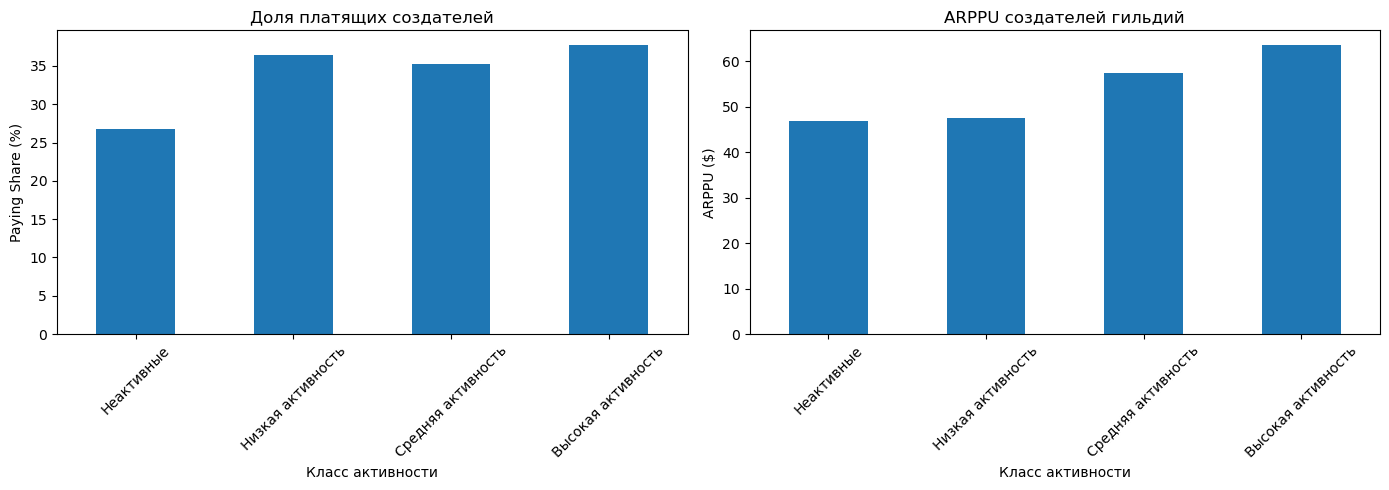

In [287]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
result['paying_share_%'].plot(kind='bar',ax=axes[0])
axes[0].set_title('Доля платящих создателей')
axes[0].set_xlabel('Класс активности')
axes[0].set_ylabel('Paying Share (%)')
axes[0].tick_params(axis='x', rotation=45)


result['arppu'].plot(kind='bar',ax=axes[1])
axes[1].set_title('ARPPU создателей гильдий')
axes[1].set_xlabel('Класс активности')
axes[1].set_ylabel('ARPPU ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
## Выводы: не можем сказать  что вторая гипотеза подтверждена.Лишь частично. Поскольку видим что,
##  разница  доли платящих между классами незначительная. Хоть и в целом тратят создали активных гильдий больше.
## Скорее всего не стоит  делать платным создание гильдии. Скорее нужно поработать над
## вопросом поочему 3 нижних класса не проходят рейды и не зарабатывают  энергию используя знания.
